
| <h1> **Hands-on Activity 9.1** </h1> | <h1> **Data Visualization using Pandas and Matplotlib** </h1> |
|--- | --- |
Name: | Cabrera, Gabriel A.<br>
Course and Section: |  CPE 311-CPE22S3<br>
Instructor: | Eng. Neal Barton James Matira
Date Performed: | March 03, 2026
Date Submitted: | March 03, 2026


<hr>


## Instructions:
- Create a Python notebook to answer all shown procedures, exercises and analysis in this section.

## Resources:
- Download the following datasets: earthquakes-1.csv Download earthquakes-1.csv, fb_stock_prices_2018.csv Download fb_stock_prices_2018.csv 


## Procedures
The procedures can be found in the canvas module. Check the following under topics:
- 9.1 Introduction to Matplotlib
- 9.2 Plotting with Pandas
- 9.3 Pandas Plotting Subpackage

### 9.1 Getting Started with Matplotlib
We need matplotlib.pyplot for plotting.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

#### About the Data
In this notebook, we will be working with 2 datasets:
- Facebook's stock price throughout 2018 (obtained using the stock_analysis package)
- Earthquake data from September 18, 2018 - October 13, 2018 (obtained from the US Geological Survey (USGS) using the USGS API)
#### Plotting lines

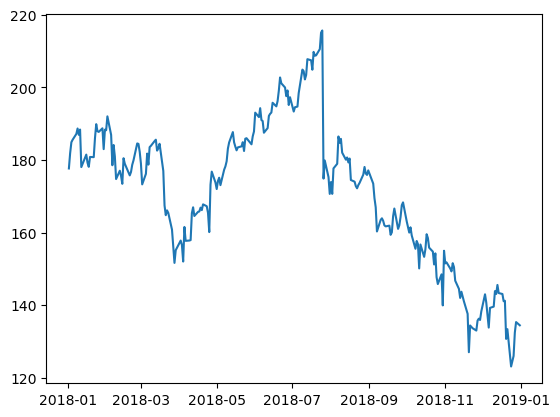

In [3]:
fb = pd.read_csv(
'fb_stock_prices_2018.csv', index_col='date', parse_dates=True
)
plt.plot(fb.index, fb.open)
plt.show()

Since we are working in a Jupyter notebook, we can use the magic command %matplotlib inline once and not have to call plt.show() for each plot.

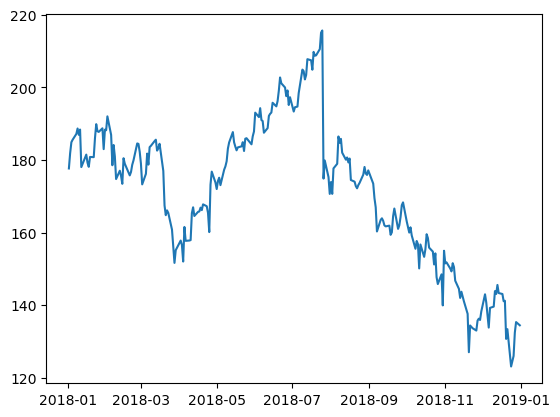

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
fb = pd.read_csv(
'fb_stock_prices_2018.csv', index_col='date', parse_dates=True
)
plt.plot(fb.index, fb.open)

### Scatter plots
We can pass in a string specifying the style of the plot. This is of the form '[color][marker][linestyle]'. For example, we can make a black dashed line with 'k--' or a red scatter plot with 'ro' 

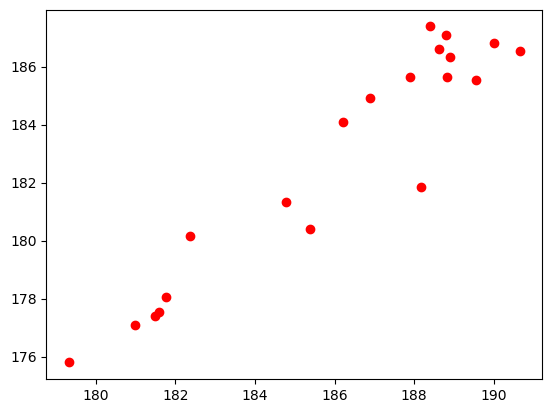

In [5]:
plt.plot('high', 'low', 'ro', data=fb.head(20))

### Histograms

(array([6.400e+01, 4.450e+02, 1.137e+03, 1.853e+03, 2.114e+03, 8.070e+02,
        2.800e+02, 9.200e+01, 9.000e+00, 2.000e+00]),
 array([-1.26 , -0.624,  0.012,  0.648,  1.284,  1.92 ,  2.556,  3.192,
         3.828,  4.464,  5.1  ]),
 <BarContainer object of 10 artists>)

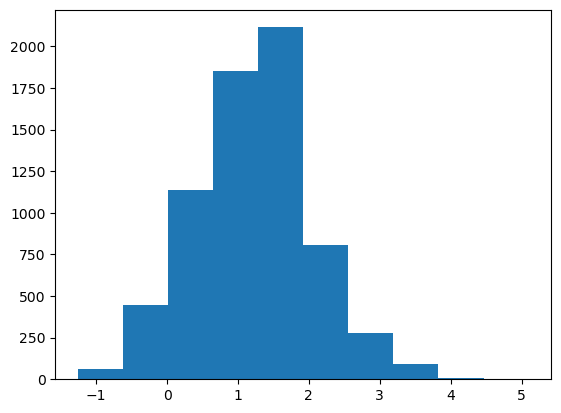

In [6]:
quakes = pd.read_csv('earthquakes.csv')
plt.hist(quakes.query('magType == "ml"').mag)

#### Bin size matters
Notice how our assumptions of the distribution of the data can change based on the number of bins (look at the drop between the two highest peaks on the righthand plot):

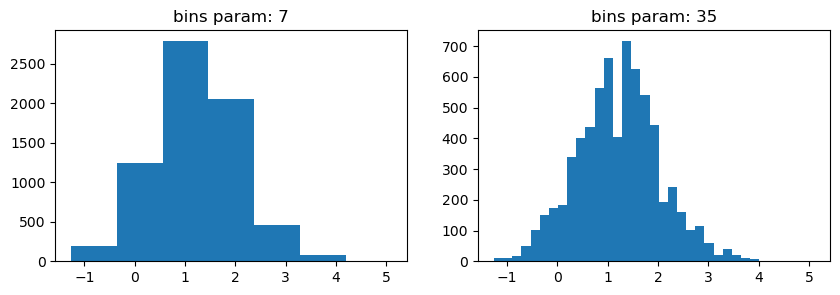

In [8]:
x = quakes.query('magType == "ml"').mag
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, bins in zip(axes, [7, 35]):
   ax.hist(x, bins=bins)
   ax.set_title(f'bins param: {bins}')

### Plot components
#### Figure
Top-level object that holds the other plot components.

In [9]:
fig = plt.figure()

<Figure size 640x480 with 0 Axes>

#### Axes
Individual plots contained within the Figure.

### Creating subplots
Simply specify the number of rows and columns to create:

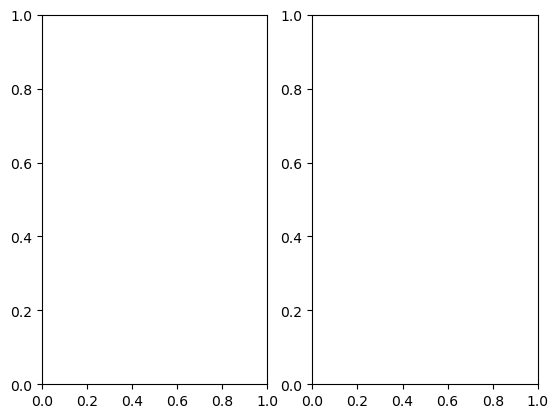

In [10]:
fig, axes = plt.subplots(1, 2)

As an alternative to using plt.subplots() we can add the Axes to the Figure on our own. This allows for some more complex layouts, such as picture in picture:

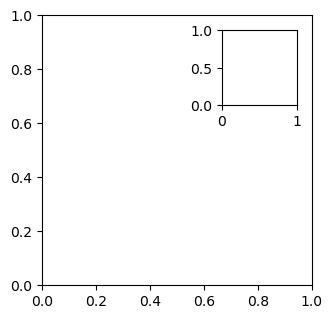

In [11]:
fig = plt.figure(figsize=(3, 3))
outside = fig.add_axes([0.1, 0.1, 0.9, 0.9])
inside = fig.add_axes([0.7, 0.7, 0.25, 0.25])

### Creating Plot Layouts with gridspec
We can create subplots with varying sizes as well:

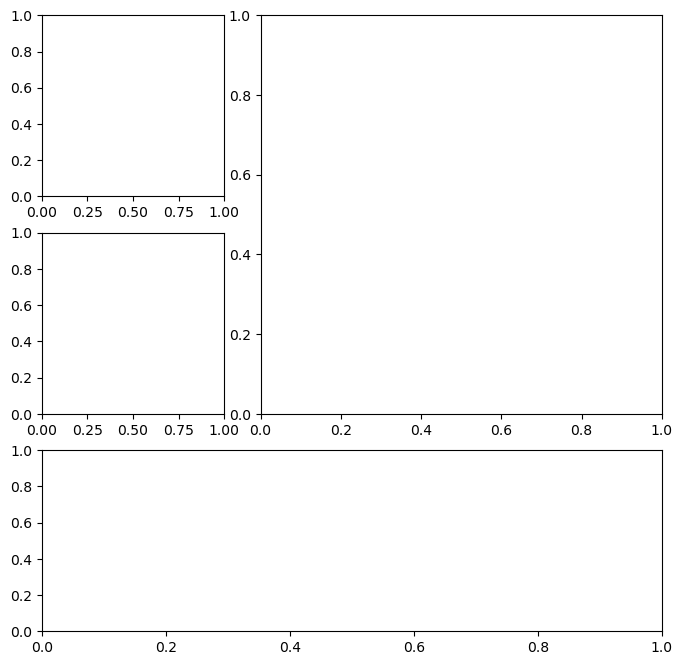

In [12]:
fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(3, 3)
top_left = fig.add_subplot(gs[0, 0])
mid_left = fig.add_subplot(gs[1, 0])
top_right = fig.add_subplot(gs[:2, 1:])
bottom = fig.add_subplot(gs[2,:])

### Saving plots
Use plt.savefig() to save the last created plot. To save a specific Figure object, use its savefig() method.

In [13]:
fig.savefig('empty.png')

### Cleaning up
It's important to close resources when we are done with them. We use plt.close() to do so. If we pass in nothing, it will close the last plot, but we can pass the specific Figure to close or say 'all' to close all Figure objects that are open. Let's close all the Figure objects that are open with plt.close() :

In [14]:
plt.close('all')

### Additional plotting options
#### Specifying figure size
Just pass the figsize parameter to plt.figure() . It's a tuple of (width, height):

In [15]:
fig = plt.figure(figsize=(10, 4))

<Figure size 1000x400 with 0 Axes>

This can be specified when creating subplots as well:

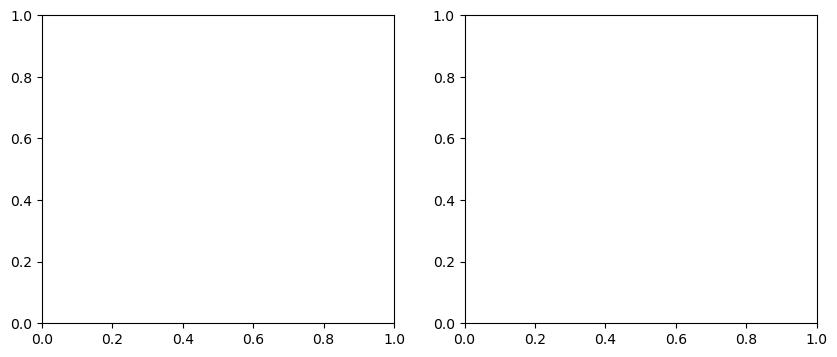

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#### rcParams
A small subset of all the available plot settings (shuffling to get a good variation of options):

In [17]:
import random
import matplotlib as mpl
rcparams_list = list(mpl.rcParams.keys())
random.seed(20) # make this repeatable
random.shuffle(rcparams_list)
sorted(rcparams_list[:20])

['axes.edgecolor',
 'axes.titleweight',
 'boxplot.whiskerprops.linestyle',
 'date.autoformatter.day',
 'figure.constrained_layout.hspace',
 'figure.titlesize',
 'image.interpolation_stage',
 'keymap.copy',
 'legend.framealpha',
 'legend.handleheight',
 'lines.dash_joinstyle',
 'lines.markerfacecolor',
 'mathtext.default',
 'mathtext.fallback',
 'pdf.compression',
 'svg.fonttype',
 'text.usetex',
 'yaxis.labellocation',
 'ytick.major.size',
 'ytick.minor.visible']

We can check the current default figsize using rcParams:

In [18]:
mpl.rcParams['figure.figsize']

[6.4, 4.8]

We can also update this value to change the default (until the kernel is restarted):

In [19]:
mpl.rcParams['figure.figsize'] = (300, 10)
mpl.rcParams['figure.figsize']

[300.0, 10.0]

Use rcdefaults() to restore the defaults:

In [20]:
mpl.rcdefaults()
mpl.rcParams['figure.figsize']

[6.4, 4.8]

This can also be done via pyplot :

In [21]:
plt.rc('figure', figsize=(20, 20)) # change figsize default to (20, 20)
plt.rcdefaults() # reset the default

### 9.2 Plotting with Pandas
The plot() method is available on Series and DataFrame objects. Many of the parameters get passed down to matplotlib. The kind argument let's us vary the plot type.

#### About the Data
In this notebook, we will be working with 2 datasets:
- Facebook's stock price throughout 2018 (obtained using the stock_analysis package)
- Earthquake data from September 18, 2018 - October 13, 2018 (obtained from the US Geological Survey (USGS) using the USGS API)

#### Setup

In [22]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
fb = pd.read_csv(
'fb_stock_prices_2018.csv', index_col='date', parse_dates=True
)
quakes = pd.read_csv('earthquakes.csv')

#### Evolution over time
Line plots help us see how a variable changes over time. They are the default for the kind argument, but we can pass kind='line' to be explicit in our intent:

<Axes: title={'center': 'Evolution of Facebook Open Price'}, xlabel='date'>

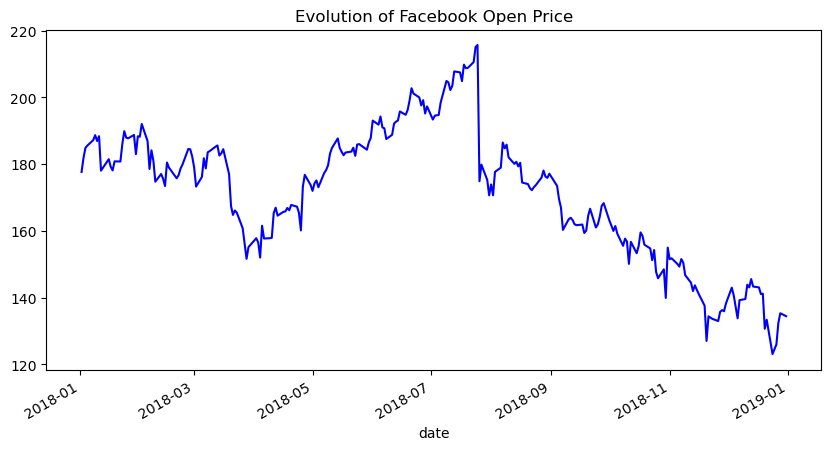

In [23]:
fb.plot(
    kind='line',
    y='open',
    figsize=(10, 5),
    style='b-',
    legend=False,
    title='Evolution of Facebook Open Price'
)

We provided the style argument in the previous example; however, we can use the color and linestyle arguments to get the same result:

<Axes: title={'center': 'Evolution of Facebook Open Price'}, xlabel='date'>

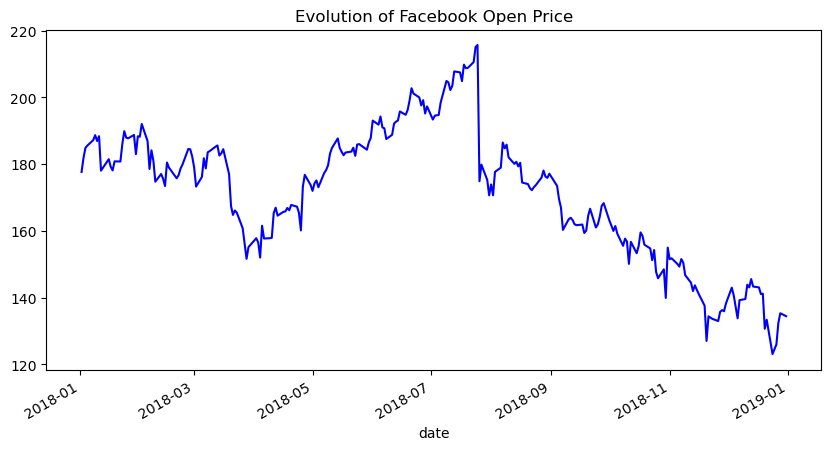

In [24]:
fb.plot(
    kind='line',
    y='open',
    figsize=(10, 5),
    color='blue',
    linestyle='solid',
    legend=False,
    title='Evolution of Facebook Open Price'
)

We can also plot many lines at once by simply passing a list of the columns to plot:

<Axes: title={'center': 'Facebook OHLC Prices during 1st Week of Trading 2018'}, xlabel='date'>

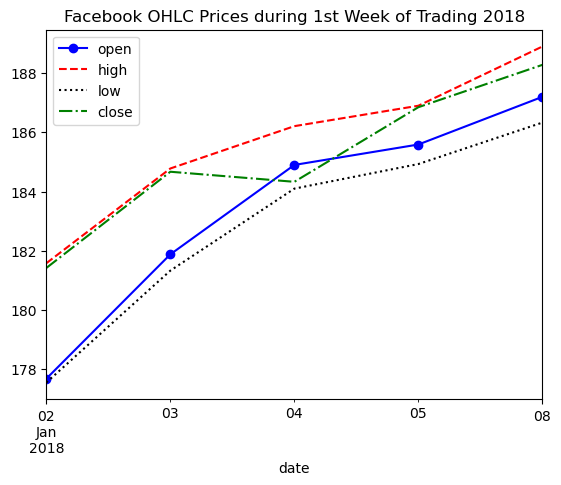

In [25]:
fb.iloc[:5,].plot(
    y=['open', 'high', 'low', 'close'],
    style=['b-o', 'r--', 'k:', 'g-.'],
    title='Facebook OHLC Prices during 1st Week of Trading 2018'
)

### Creating subplots
When plotting with pandas, creating subplots is simply a matter of passing subplots=True to the plot() method, and (optionally) specifying the layout in a tuple of (rows, columns):

array([[<Axes: xlabel='date'>, <Axes: xlabel='date'>],
       [<Axes: xlabel='date'>, <Axes: xlabel='date'>],
       [<Axes: xlabel='date'>, <Axes: xlabel='date'>]], dtype=object)

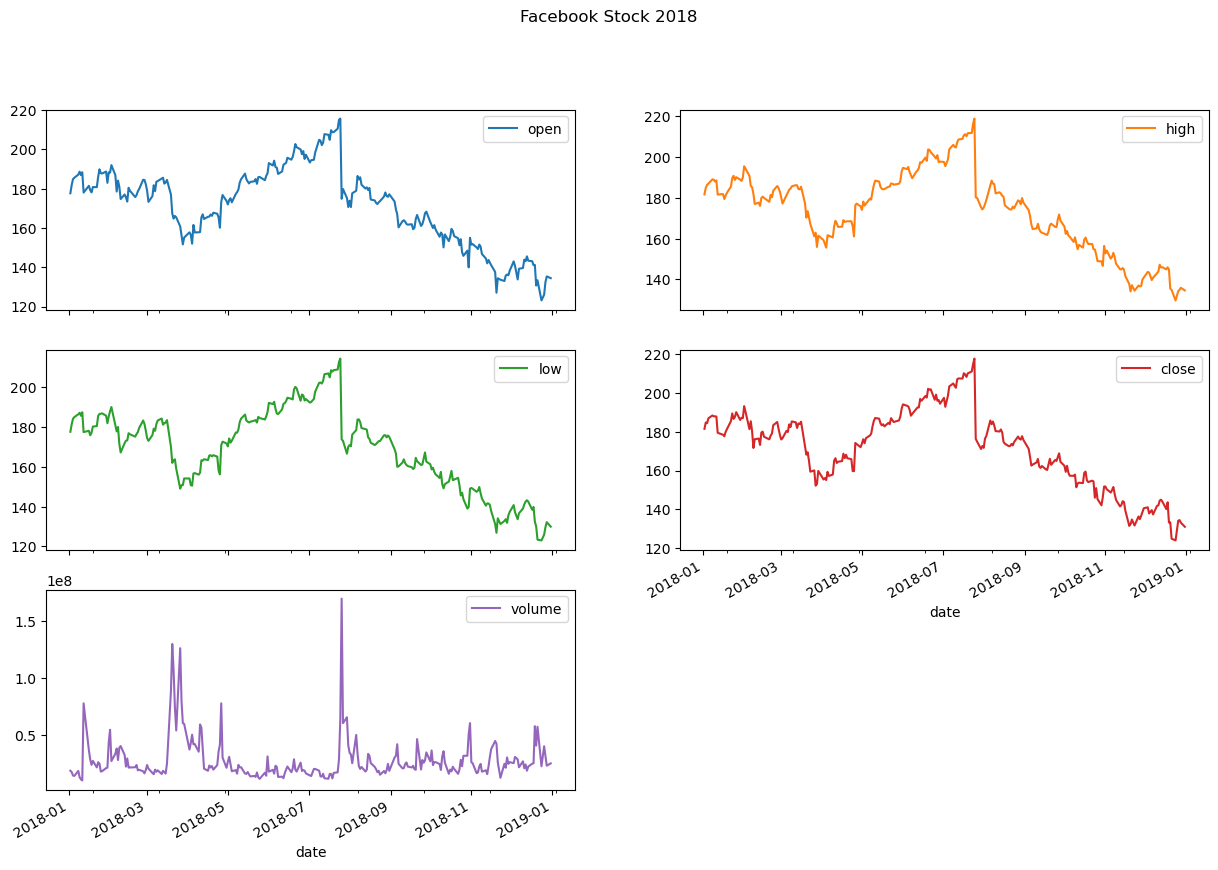

In [26]:
fb.plot(
    kind='line',
    subplots=True,
    layout=(3,2),
    figsize=(15,10),
    title='Facebook Stock 2018'
)

Note that we didn't provide a specific column to plot and pandas plotted all of them for us.
### Visualizing relationships between variables
#### Scatter plots
We make scatter plots to help visualize the relationship between two variables. Creating scatter plots requires we pass in kind='scatter' along with a column for the x-axis and a column for the y-axis:

<Axes: title={'center': 'Facebook Daily High - Low vs. Volume Traded'}, xlabel='volume', ylabel='max_abs_change'>

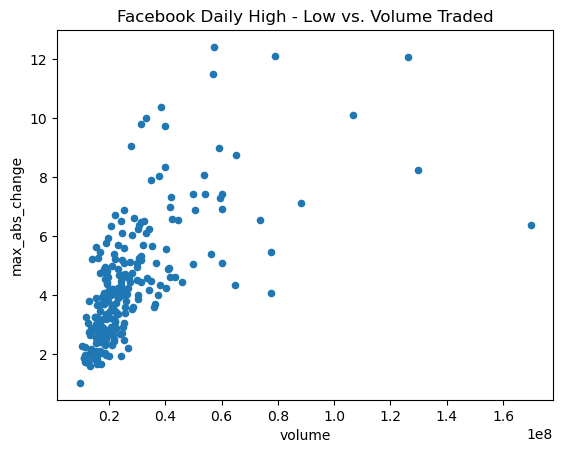

In [28]:
fb.assign(
    max_abs_change=fb.high - fb.low
).plot(
    kind='scatter', x='volume', y='max_abs_change',
    title='Facebook Daily High - Low vs. Volume Traded'
)

The relationship doesn't seem to be linear, but we can try a log transform on the x-axis since the scales of the axes are very different. With pandas, we simply pass in logx=True: 

<Axes: title={'center': 'Facebook Daily High - Low vs. log(Volume Traded)'}, xlabel='volume', ylabel='max_abs_change'>

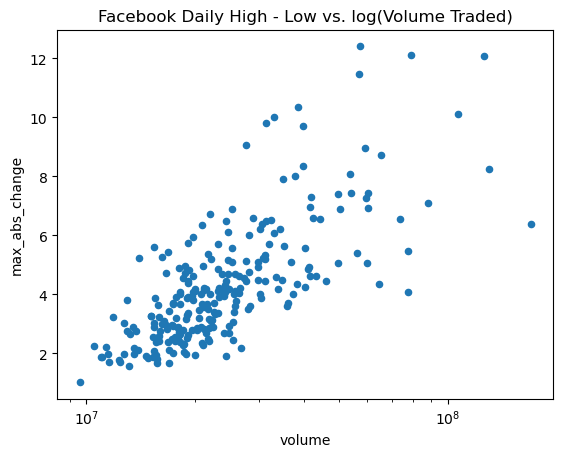

In [29]:
fb.assign(
    max_abs_change=fb.high - fb.low
).plot(
    kind='scatter', x='volume', y='max_abs_change',
    title='Facebook Daily High - Low vs. log(Volume Traded)',
    logx=True
)

With matplotlib, we could use plt.xscale('log') to do the same thing.
#### Adding Transparency to Plots with alpha
Sometimes our plots have many overlapping values, but this can be impossible to see. This can be addressed by increasing the transparency of what we are plotting using the alpha parameter. It is a float on [0, 1] where 0 is completely transparent and 1 is completely opaque. By default this is 1, so let's put in a lower value and re-plot the scatter plot:

<Axes: title={'center': 'Facebook Daily High - Low vs. log(Volume Traded)'}, xlabel='volume', ylabel='max_abs_change'>

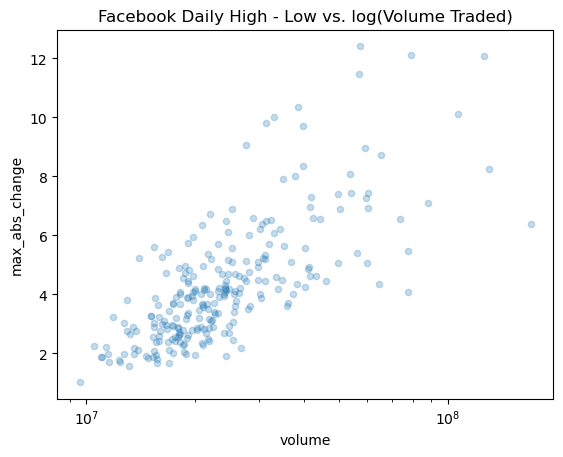

In [30]:
fb.assign(
    max_abs_change=fb.high - fb.low
).plot(
    kind='scatter', x='volume', y='max_abs_change',
    title='Facebook Daily High - Low vs. log(Volume Traded)',
    logx=True, alpha=0.25
)

## Data Analysis
### 9.1 Introduction to Matplotlib
Since I already learned how to use Matplotlib in other courses such as Visualization and Data Analysis and Emerging Technologies 1, this section helped me review them and show the fundamental features of Matplotlib. They seem very basic but this is the foundation of data visualization and analysis, making it easier for people to see what a data means and how they tell a story.
### 9.2 Plotting with Pandas
A continuation of the previous section, but this time it shows which diagram we should use to visualize data more efficiently, this also discusses about making the visualizations more appealing and understandable, making it better to understand and pull out insights even for people with little to no knowledge of data analysis.

## Supplementary Activity:

Using the CSV files provided and what we have learned so far in this module complete the following exercises:

1. Plot the rolling 20-day minimum of the Facebook closing price with the pandas plot() method.

2. Create a histogram and KDE of the change from open to close in the price of Facebook stock.

3. Using the earthquake data, create box plots for the magnitudes of each magType used in Indonesia.

4. Make a line plot of the difference between the weekly maximum high price and the weekly minimum low price for Facebook. This should be a single line.

5. Using matplotlib and pandas, create two subplots side-by-side showing the effect that after-hours trading has had on Facebook's stock price:

- The first subplot will contain a line plot of the daily difference between that day's opening price and the prior day's closing price (be sure to review the Time series section of Aggregating Pandas DataFrames for an easy way to do this).

- The second subplot will be a bar plot showing the net effect this had monthly, using resample().

- Bonus #1: Color the bars according to whether they are gains in the stock price (green) or drops in the stock price (red).

- Bonus #2: Modify the x-axis of the bar plot to show the threeletter abbreviation for the month.


<Axes: title={'center': 'Facebook 20-day Rolling Minimum Closing Price'}, xlabel='date'>

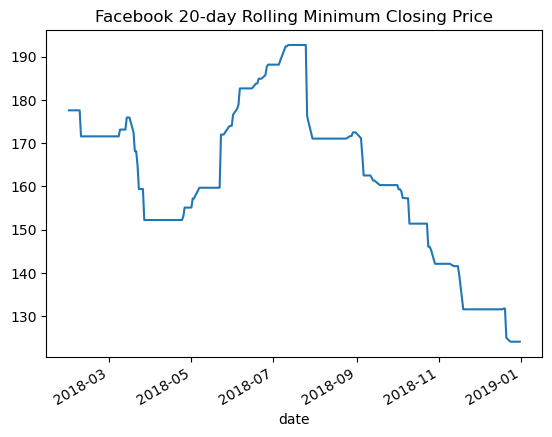

In [31]:
#1. Plot the rolling 20-day minimum of the Facebook closing price with the pandas plot() method.
fb['rolling_min'] = fb.close.rolling(window=20).min()
fb.rolling_min.plot(title='Facebook 20-day Rolling Minimum Closing Price')

<Axes: title={'center': 'KDE of Facebook Open-Close Price Change'}, ylabel='Density'>

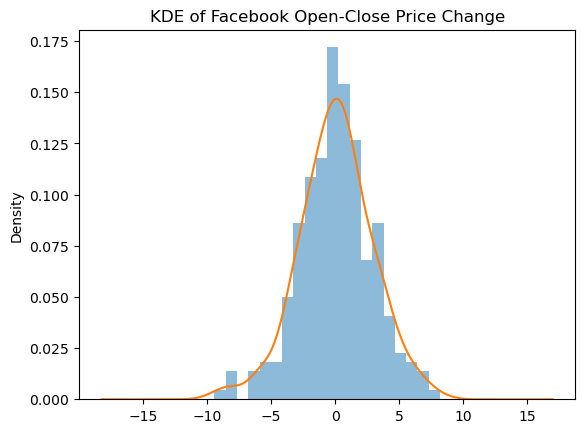

In [32]:
#2. Create a histogram and KDE of the change from open to close in the price of Facebook stock.
fb['open_close_change'] = fb.close - fb.open
fb.open_close_change.plot(kind='hist', bins=20, density=True, alpha=0.5, title='Histogram of Facebook Open-Close Price Change')
fb.open_close_change.plot(kind='kde', title='KDE of Facebook Open-Close Price Change')

Text(0.5, 0.98, '')

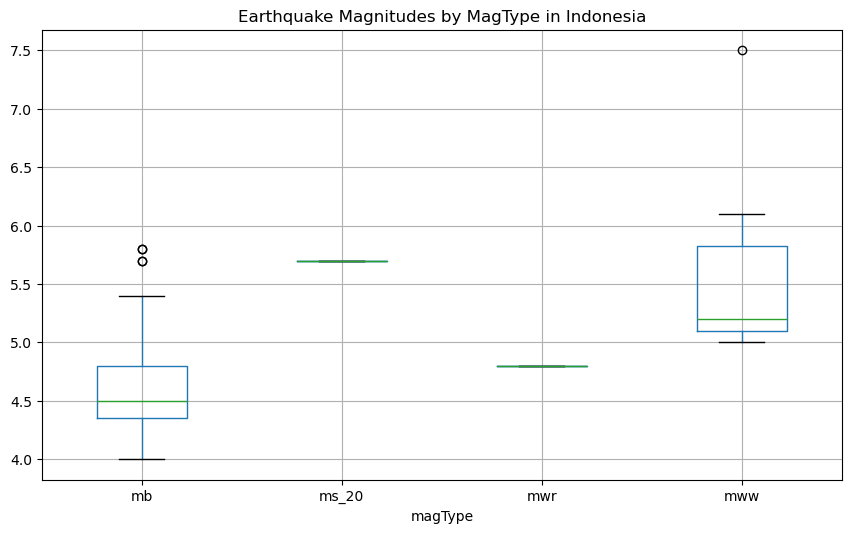

In [46]:
#3. Using the earthquake data, create box plots for the magnitudes of each magType used in Indonesia.
earthquakes=pd.read_csv('earthquakes-1.csv')
indonesia_earthquakes = earthquakes[earthquakes.parsed_place == 'Indonesia']
indonesia_earthquakes.boxplot(column='mag', by='magType', figsize=(10, 6))
plt.title('Earthquake Magnitudes by MagType in Indonesia')
plt.suptitle('')

<Axes: title={'center': 'Difference between Weekly Max High and Min Low for Facebook'}, xlabel='date'>

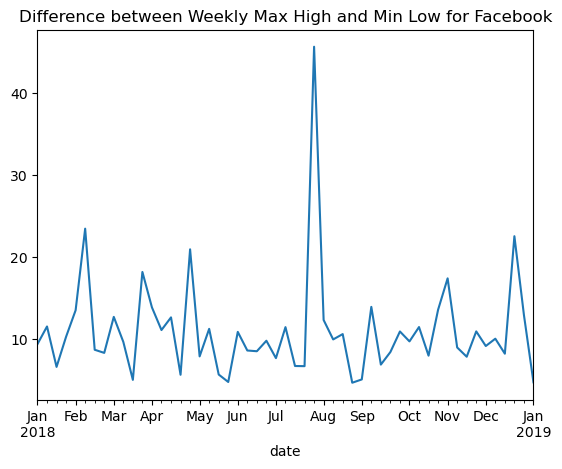

In [36]:
#4. Make a line plot of the difference between the weekly maximum high price and the weekly minimum low price for Facebook. This should be a single line.
weekly_max_high = fb.high.resample('W').max()
weekly_min_low = fb.low.resample('W').min()
weekly_diff = weekly_max_high - weekly_min_low
weekly_diff.plot(title='Difference between Weekly Max High and Min Low for Facebook')

[Text(0, 0, 'Jan'),
 Text(1, 0, 'Feb'),
 Text(2, 0, 'Mar'),
 Text(3, 0, 'Apr'),
 Text(4, 0, 'May'),
 Text(5, 0, 'Jun'),
 Text(6, 0, 'Jul'),
 Text(7, 0, 'Aug'),
 Text(8, 0, 'Sep'),
 Text(9, 0, 'Oct'),
 Text(10, 0, 'Nov'),
 Text(11, 0, 'Dec')]

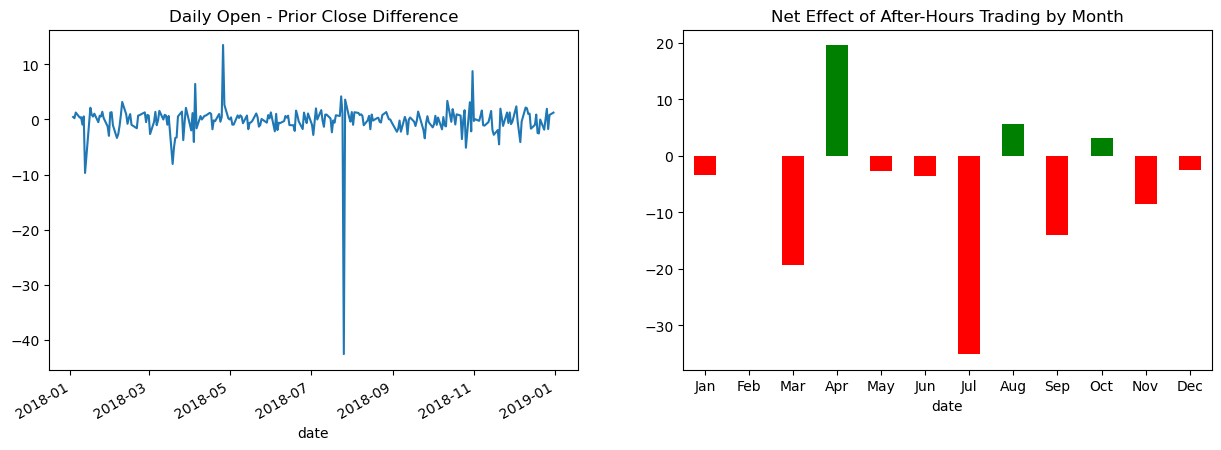

In [40]:
#5. Using matplotlib and pandas, create two subplots side-by-side showing the effect that after-hours trading has had on Facebook's stock price:
fb['daily_open_close_diff'] = fb.open - fb.close.shift(1)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fb.daily_open_close_diff.plot(ax=axes[0], title='Daily Open - Prior Close Difference')
monthly_diff = fb.daily_open_close_diff.resample('ME').sum()
monthly_diff.plot(kind='bar', ax=axes[1], title='Net Effect of After-Hours Trading by Month', color=monthly_diff.apply(lambda x: 'green' if x > 0 else 'red'))
axes[1].set_xticklabels(monthly_diff.index.strftime('%b'), rotation=0)

## Conclusion
Through this activity, I was able to reinforce my previous knowledge on data visualizations using matplotlib and pandas. By creating specialized charts like histograms, KDEs, and box plots, I was able to better analyze data distributions and identify specific trends, such as price fluctuations in Facebook stock and seismic activity patterns in countries like Indonesia. 

I also practiced more advanced techniques, such as generating subplots that are beside each other and using resampling to observe monthly net effects. This was particularly useful in understanding how to manipulate time series data to show the relationship between different variables over time.
